# 프로젝트 2 - Weekend 1: RAG 평가 프레임워크와 하이브리드 검색

**프로젝트**: 검색형 RAG 기반 금융 상품(ETF) 추천 시스템

**학습 목표**:
1. ETF 데이터셋을 구축하고 벡터 스토어에 색인
2. Hit Rate, MRR, NDCG 등 검색 평가 지표 구현
3. BM25 + 벡터 하이브리드 검색으로 성능 개선
4. Query Expansion과 Multi-Query로 검색 품질 극대화

# 📖 내용 복습
## 검색 평가 메트릭

### 📄 실습 1 (3/31) — 검색 평가 메트릭 1
- FAISS vectorstore의 `similarity_search_with_score`로 유사도 검색 수행 및 캐싱

| 항목 | 내용 |
|------|------|
| 핵심 개념 | Hit Rate@K, MRR, DCG/nDCG |
| 주요 함수 | `hit_rate_at_k()`, `reciprocal_rank()`, `dcg_at_k()`, `ndcg_at_k()` |
| 핵심 패턴 | FAISS 벡터스토어 + `search_results_cache` 딕셔너리로 검색 결과 캐싱 |
| 배운 것 | 랭킹 기반 메트릭의 직관, 정답 위치가 점수에 미치는 영향 |

### 📄 실습 2 (4/1) — 검색 평가 메트릭 2

| 항목 | 내용 |
|------|------|
| 핵심 개념 | TP/FP/FN/TN, Precision@K, Recall@K, F1, R-Precision, F-beta, BLEU, LLM-as-judge |
| 주요 함수 | `precision_at_k()`, `recall_at_k()`, `f1_at_k()`, `r_precision()`, `f_beta_at_k()`, `bleu_score()` |
| 핵심 패턴 | 혼동 행렬 → 랭킹 메트릭 → 생성 메트릭 → LLM 평가자 순서 |
| 배운 것 | Precision↑ = 노이즈 감소, Recall↑ = 누락 감소, 도메인에 따른 β 선택 |

### 📄 실습 3-4 (4/2) — 하이브리드 검색 & 쿼리 확장

| 항목 | 내용 |
|------|------|
| 핵심 개념 | TF-IDF, BM25, FAISS, EnsembleRetriever, RRF, kiwipiepy, Multi-Query, HyDE |
| 주요 클래스 | `TFIDF`, `BM25`, `BM25Retriever`, `EnsembleRetriever` |
| 핵심 패턴 | 키워드 검색과 벡터 검색의 RRF 기반 점수 통합, 그리드 서치로 α 최적화 |
| 배운 것 | 키워드 검색 강점(고유명사/신조어), 벡터 검색 강점(의미 유사), 쿼리 변환으로 recall 향상 |

In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

In [2]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [3]:
import os
import json
import numpy as np
import pandas as pd
# from dotenv import load_dotenv
# load_dotenv()
from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

client = OpenAI()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


---
## 데이터 준비

아래 셀을 실행하면 ETF 금융 상품 데이터가 로드됩니다.

In [4]:
# ============================================================
# ETF 금융 상품 샘플 데이터 (실습용)
# ============================================================
SAMPLE_ETF_DATA = [
    {"ticker": "KODEX200", "name": "KODEX 200", "category": "국내주식",
     "description": "KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심으로 구성되어 있으며, 국내 주식시장 전체의 흐름을 반영합니다.",
     "expense_ratio": 0.15, "aum_billion": 58000, "risk_level": "중간",
     "returns": {"1m": 2.1, "3m": 5.4, "1y": 12.3, "3y": 28.5},
     "keywords": ["코스피", "대형주", "인덱스", "패시브"]},
    {"ticker": "TIGER미국S&P500", "name": "TIGER 미국 S&P500", "category": "해외주식",
     "description": "미국 S&P500 지수를 추종. 애플, 마이크로소프트, 아마존 등 미국 대형 기술주 포함. 환헤지 미적용으로 원/달러 환율 변동에 노출됩니다.",
     "expense_ratio": 0.07, "aum_billion": 42000, "risk_level": "중간",
     "returns": {"1m": 3.2, "3m": 8.1, "1y": 18.7, "3y": 45.2},
     "keywords": ["미국", "S&P500", "대형주", "기술주"]},
    {"ticker": "KODEX미국나스닥100", "name": "KODEX 미국나스닥100", "category": "해외주식",
     "description": "나스닥100 지수 추종. 기술 성장주 중심으로 애플, 엔비디아, 메타 등 포함. 고성장/고변동성 특성으로 공격적 투자자에게 적합합니다.",
     "expense_ratio": 0.09, "aum_billion": 35000, "risk_level": "높음",
     "returns": {"1m": 4.5, "3m": 12.3, "1y": 25.1, "3y": 62.8},
     "keywords": ["나스닥", "기술주", "성장주", "AI"]},
    {"ticker": "KODEX국고채10년", "name": "KODEX 국고채 10년", "category": "채권",
     "description": "대한민국 10년 만기 국고채를 추종하는 채권 ETF. 금리 인하 시 가격 상승, 안전자산 선호 시 수요 증가. 변동성이 낮아 안정적 투자에 적합합니다.",
     "expense_ratio": 0.05, "aum_billion": 12000, "risk_level": "낮음",
     "returns": {"1m": 0.8, "3m": 1.5, "1y": 4.2, "3y": 8.1},
     "keywords": ["국채", "채권", "안전자산", "금리"]},
    {"ticker": "TIGER금은혼합", "name": "TIGER 금은혼합", "category": "원자재",
     "description": "금과 은에 분산 투자하는 원자재 ETF. 인플레이션 헤지 수단으로 활용되며, 지정학적 리스크 시 안전자산으로 수요 증가합니다.",
     "expense_ratio": 0.39, "aum_billion": 3500, "risk_level": "중간",
     "returns": {"1m": 1.2, "3m": 3.8, "1y": 15.6, "3y": 35.2},
     "keywords": ["금", "은", "원자재", "인플레이션"]},
    {"ticker": "KODEX리츠", "name": "KODEX 한국부동산리츠인프라", "category": "부동산",
     "description": "국내 상장 리츠 및 인프라 펀드에 투자. 임대료 수입 기반의 안정적 배당 수익을 제공하며, 부동산 간접투자 수단으로 활용됩니다.",
     "expense_ratio": 0.09, "aum_billion": 4800, "risk_level": "중간",
     "returns": {"1m": -0.5, "3m": 2.1, "1y": 7.8, "3y": 15.3},
     "keywords": ["리츠", "부동산", "배당", "임대"]},
    {"ticker": "KODEX2차전지", "name": "KODEX 2차전지산업", "category": "테마",
     "description": "2차전지(배터리) 관련 기업에 집중 투자. LG에너지솔루션, 삼성SDI, 포스코퓨처엠 등 포함. 전기차 시장 성장에 따른 수혜가 기대됩니다.",
     "expense_ratio": 0.45, "aum_billion": 18000, "risk_level": "높음",
     "returns": {"1m": -2.3, "3m": -5.1, "1y": -12.4, "3y": 8.7},
     "keywords": ["2차전지", "배터리", "전기차", "테마"]},
    {"ticker": "TIGERBBD", "name": "TIGER 미국배당다우존스", "category": "배당",
     "description": "미국 고배당 우량주에 투자하는 ETF. 안정적인 배당 수익과 자본 이득을 동시에 추구합니다. 월배당 지급으로 현금흐름 관리에 유리합니다.",
     "expense_ratio": 0.01, "aum_billion": 52000, "risk_level": "낮음",
     "returns": {"1m": 1.8, "3m": 4.2, "1y": 10.5, "3y": 32.1},
     "keywords": ["배당", "미국", "월배당", "인컴"]},
    {"ticker": "KODEXKSM", "name": "KODEX 코스닥150", "category": "국내주식",
     "description": "코스닥 150 지수를 추종. 중소형 성장주 중심으로 바이오, IT, 게임 등 혁신 기업 포함. 코스피 대비 높은 변동성과 성장 잠재력을 가집니다.",
     "expense_ratio": 0.20, "aum_billion": 8500, "risk_level": "높음",
     "returns": {"1m": -1.2, "3m": 3.5, "1y": 8.9, "3y": 18.7},
     "keywords": ["코스닥", "중소형", "성장주", "바이오"]},
    {"ticker": "KOSEF단기자금", "name": "KOSEF 단기자금", "category": "머니마켓",
     "description": "초단기 채권 및 예금에 투자하는 MMF형 ETF. 원금 손실 위험이 극히 낮으며, 여유 자금 파킹 용도로 활용됩니다. 하루 단위 이자 발생.",
     "expense_ratio": 0.03, "aum_billion": 25000, "risk_level": "매우낮음",
     "returns": {"1m": 0.3, "3m": 0.9, "1y": 3.5, "3y": 10.2},
     "keywords": ["단기", "파킹", "안전", "예금"]},
]

# 사용자 프로필 데이터
SAMPLE_USER_PROFILES = [
    {"user_id": "U001", "name": "김초보", "level": "초보",
     "risk_tolerance": "낮음", "investment_goal": "안정적 수익",
     "monthly_budget": 500000, "preferred_categories": ["채권", "머니마켓"],
     "sample_queries": ["안전한 투자 상품 추천해주세요", "원금 손실 없는 ETF가 뭐가 있나요?"]},
    {"user_id": "U002", "name": "이중급", "level": "중급",
     "risk_tolerance": "중간", "investment_goal": "자산 증식",
     "monthly_budget": 2000000, "preferred_categories": ["국내주식", "해외주식"],
     "sample_queries": ["S&P500 추종 ETF 비교해주세요", "배당과 성장 균형 잡힌 포트폴리오 추천"]},
    {"user_id": "U003", "name": "박전문", "level": "전문",
     "risk_tolerance": "높음", "investment_goal": "공격적 수익",
     "monthly_budget": 10000000, "preferred_categories": ["테마", "해외주식"],
     "sample_queries": ["AI 관련 ETF 섹터 분석해줘", "나스닥100 vs 코스닥150 변동성 비교"]},
]

# 평가용 질의 데이터
SAMPLE_EVAL_QUERIES = [
    {"query": "초보자인데 안전한 투자 추천해주세요", "expected_tickers": ["KODEX국고채10년", "KOSEF단기자금", "TIGERBBD"]},
    {"query": "미국 기술주에 투자하고 싶어요", "expected_tickers": ["TIGER미국S&P500", "KODEX미국나스닥100"]},
    {"query": "월배당 받을 수 있는 ETF 있나요?", "expected_tickers": ["TIGERBBD", "KODEX리츠"]},
    {"query": "전기차 관련 투자 상품 알려주세요", "expected_tickers": ["KODEX2차전지"]},
    {"query": "인플레이션 헤지용 상품 추천", "expected_tickers": ["TIGER금은혼합", "KODEX리츠"]},
    {"query": "분산투자 포트폴리오 짜주세요", "expected_tickers": ["KODEX200", "TIGER미국S&P500", "KODEX국고채10년"]},
]

print(f"📦 ETF 데이터 로드 완료: {len(SAMPLE_ETF_DATA)}개 상품, {len(SAMPLE_USER_PROFILES)}개 프로필, {len(SAMPLE_EVAL_QUERIES)}개 평가 질의")
for cat in sorted(set(e["category"] for e in SAMPLE_ETF_DATA)):
    cnt = sum(1 for e in SAMPLE_ETF_DATA if e["category"] == cat)
    print(f"  - {cat}: {cnt}개")

📦 ETF 데이터 로드 완료: 10개 상품, 3개 프로필, 6개 평가 질의
  - 국내주식: 2개
  - 머니마켓: 1개
  - 배당: 1개
  - 부동산: 1개
  - 원자재: 1개
  - 채권: 1개
  - 테마: 1개
  - 해외주식: 2개


---
## 문제 1: ETF 사용자 페르소나 정의

ETF 추천 시스템의 사용자 페르소나 3가지(초보/중급/전문)를 정의하세요.

**요구사항:**
- `personas` 딕셔너리: 키='초보'/'중급'/'전문'
- 각 페르소나에 `description`(설명)과 `queries`(질의 리스트) 포함
- 각 질의에 `query`(질문 텍스트)와 `expected_category`(기대 카테고리) 포함
- `project2_data/query_set.json`으로 저장

In [5]:
# 투자자 구분 기준
  # 지식(Knowledge): 금융 용어, 경제 지표, 재무제표 해독, 자산 클래스 이해
  # 경험(Experience): 실제 투자 기간, 거래 횟수, 다양한 시장 사이클 경험
  # 운용 자산 규모(Assets Under Management): 투자 가능 금액, 순자산
  # 리스크 인식 및 전략(Risk & Strategy): 손실 허용 범위, 포트폴리오 다각화 이해

# 문제 1: 사용자 페르소나 정의
personas = {
    "초보": {
        "description": """투자 기간은 2년 미만이며,
                          경제/금융 용어 및 재무제표와 사업 및 자산 영역별 이해도가 전무합니다.
                          일상적으로 접하는 신문 또는 뉴스에서 소식들을 접하는 편이며
                          운용 자산 규모는 '상'/'중'/'하' 중 '하'에 속합니다.
                          리스크 인식 및 대처 방법에 대한 지식과 경험이 전무합니다.
                      """,  # 투자 경험 설명
       "queries": [
            {"query": "요즘 뉴스에서 금리가 오른다는데, 원금 잃지 않고 안전하게 투자할 수 있는 곳이 있을까요?",
             "expected_category": ["안전 자산", "예적금/채권 입문"]},
            {"query": "최근에 인공지능 관련 주식이 많이 올랐다던데, 지금 조금 사봐도 괜찮은가요?",
             "expected_category": ["주식 시황", "단순 투자 추천"]},
            {"query": "매달 30만 원씩 여유 돈이 생기는데, 주식 말고 어떻게 돈을 굴려야 할지 하나도 모르겠어요.",
             "expected_category": ["소액 투자", "기초 재무설계"]},
        ]
    },
    "중급": {
        "description": """투자 기간은 2년 이상 5년 미만이며,
                          경제/금융 및 재무제표의 극히 일부 용어들에 대해 접한 경험이 있으나 완벽하게 숙지는 못한 상태입니다.
                          사업 분야에 대해서 "기술, 원료, 식품, 금융, 의학 등"의 분야로 나눠 이해하며,
                          자산 영역에 대해, "채권, 주식, 원자재(원유, 금속 등)"에 대해 구분이 가능하지만 이들 간의 연관성은 파악하지 못합니다.
                          경제 주기(사이클)에 관하여, 하나의 주기를 경험한 바 있으며, 경제 정책과의 상관성은 어렴풋이 파악하는 편입니다.
                          투자 정보는 주식 관련 전문 투자 사이트 및 커뮤니티와 경제 전문지 등에서 접하는 편이며
                          운용 자산 규모는 '상'/'중'/'하' 중 '중'에 속합니다.
                          리스크 인식은 할 수 있는 편이지만, 대처 방법에 대한 지식과 경험은 전무합니다.
                      """,
        "queries": [
            {"query": "올해 미국 금리가 인하될 것 같은데, 지금 가진 기술주 비중을 줄이고 배당주나 채권 쪽으로 옮겨가는 게 맞을까요?",
             "expected_category": ["자산 배분", "섹터 전략"]},
            {"query": "반도체 관련 주식을 계속 모으고 있었는데 최근에 너무 많이 떨어졌습니다. 손절을 해야 할지, 더 기다려야 할지 판단이 잘 안 섭니다.",
             "expected_category": ["리스크 관리", "포트폴리오 점검"]},
            {"query": "주식에만 투자하다 보니 좀 불안해서 금이나 달러 투자도 해보고 싶은데, 비중을 어떻게 나누는 게 좋을까요?",
             "expected_category": ["포트폴리오 다각화", "대체 투자"]},
        ]
            },
    "전문": {
        "description": """투자 기간은 5년 이상이며, 상승장과 하락장 등 다양한 경제 사이클을 두 번 이상 경험했습니다.
                          거시 경제 지표(금리, 환율, 인플레이션 등)와 미시적 지표(기업 재무제표, 현금흐름, 비즈니스 모델)를 깊이 있게 분석하고 해독할 수 있습니다.
                          주식, 채권, 원자재, 외환 등 다양한 자산 클래스 간의 상관관계를 명확히 이해하고 교차 분석을 진행합니다.
                          투자 정보는 기업 공시(DART, SEC 등), 중앙은행 발표 자료, 글로벌 경제 지표 등 1차 출처를 주로 참고하며,
                          운용 자산 규모는 '상'/'중'/'하' 중 '상'에 속합니다.
                          리스크를 적극적으로 관리하며, 하락장에 대비한 헤징(Hedging) 전략과 정교한 포트폴리오 리밸런싱 지식 및 경험을 보유하고 있습니다.
                      """,
        "queries": [
            {"query": "최근 물가 지표가 예상보다 꺾이지 않고 있는데, 달러 자산과 원자재 비중을 현재 30%에서 더 늘리는 방향에 대해 어떻게 보시나요?",
             "expected_category": ["거시 경제", "전략적 리밸런싱"]},
            {"query": "관심 있게 보는 기업의 매출은 꾸준히 늘고 있지만 잉여현금흐름(FCF)이 둔화되고 있습니다. 이 상황에서 장기적인 기업 가치를 어떻게 평가하는 것이 합리적일까요?",
             "expected_category": ["기업 가치 평가", "재무제표 심층 분석"]},
            {"query": "하반기 경기 둔화 우려가 커지면서 포트폴리오 변동성을 줄이고 싶습니다. 현재의 주식 비중을 유지하면서도 효과적으로 하락 리스크를 방어(헤지)할 방법이 있을까요?",
             "expected_category": ["리스크 헤징", "고급 포트폴리오 전략"]},
        ]
    },
}

os.makedirs("/content/sample_data/project2_data", exist_ok=True)

# JSON 저장
with open("/content/sample_data/project2_data/query_set.json", "w") as f:
    json.dump(personas, f, ensure_ascii=False, indent=2)

print(f"✅ {sum(len(p['queries']) for p in personas.values())}개 질의 저장 완료")

✅ 9개 질의 저장 완료


---
## 문제 2: 추가 ETF 문서 생성

5개 추가 ETF(ESG, 2차전지, 헬스케어, 리츠, 원자재)를 정의하고 LLM으로 설명을 생성하세요.

**요구사항:**
- `additional_etfs` 리스트: 5개 ETF (name, category, market)
- `risk_map` 딕셔너리: 카테고리별 위험도 매핑
- 각 ETF에 대해 `client.chat.completions.create()`로 설명 생성
  - `client.chat.completions.create()`는 OpenAI API의 채팅 완성 메서드로, model과 messages 파라미터를 필수로 요구
    ```python
        client.chat.completions.create(
          model="gpt-4o",          # 필수: 사용할 모델명
          messages=[               # 필수: 대화 메시지 리스트
              {"role": "system", "content": "..."},   # 시스템 지시
              {"role": "user",   "content": "..."},   # 사용자 입력
          ],
          temperature=0.7,         # 선택: 창의성 조절 (0~2)
          max_tokens=1024,         # 선택: 최대 출력 토큰
      )
    ```

- `etf_documents`에 추가 후 카테고리별 통계 출력

In [6]:
# 문제 2: 추가 ETF 정의 및 문서 생성
additional_etfs = [
    {"name": "TIGER ESG리더스", "category": "ESG", "market": "국내"},
    {"name": "VanEck Semiconductor ETF", "category": "반도체", "market": "미국"},
    {"name": "ARK Genomic Revolution ETF", "category": "바이오","market": "미국"},
    {"name": "iShares U.S. Aerospace & Defense ETF", "category": "우주항공", "market": "미국"},
    {"name": "Global X AI & Technology ETF", "category": "인공지능", "market": "미국"},
]

risk_map = {
    # 카테고리: 위험도(1~5) 매핑
    "ESG":          2,
    "2차전지":       4,
    "헬스케어":      3,
    "리츠":          2,
    "원자재":        3,
    "반도체":        4,
    "바이오":        5,
    "우주항공":      4,
    "인공지능":      4,
}

etf_documents = []

for idx, etf in enumerate(additional_etfs):
    # ---- 여기에 코드 작성 ----
    # 1) client.chat.completions.create()로 ETF 설명 생성
      # client = OpenAI()

  response = client.chat.completions.create(
      model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": "당신은 경제 금융 및 ETF 전문가입니다. ETF의 특징, 투자 포인트, 위험도를 간단명료하게 설명하세요."
            },
            {
                "role": "user",
                "content": (
                    f"""
                    다음 ETF 리스트 정보를 참고하세요:\n{etf}\n\n,
                    두 줄 미만으로 핵심만 요약하여 설명해주세요."""
                )
            }
        ]
  )
  description = response.choices[0].message.content

  # 2) etf_documents에 추가
  etf_documents.append({
          "doc_id": idx,
          "name": etf["name"],
          "category": etf["category"],
          "market": etf["market"],
          "risk": risk_map[etf["category"]],
          "description": description
      })

df = pd.DataFrame(etf_documents)
print(f"카테고리별 수:\n{df['category'].value_counts()}")

카테고리별 수:
category
ESG     1
반도체     1
바이오     1
우주항공    1
인공지능    1
Name: count, dtype: int64


In [7]:
etf_documents

[{'doc_id': 0,
  'name': 'TIGER ESG리더스',
  'category': 'ESG',
  'market': '국내',
  'risk': 2,
  'description': "'TIGER ESG리더스'는 국내 ESG 투자에 초점을 둔 ETF로, 환경, 사회, 지배구조를 고려한 기업에 투자합니다. 지속 가능한 투자를 통해 장기적인 성장 잠재력을 추구하지만, ESG 기준에 따른 시장 변동성과 정책 변화에 따른 위험이 존재합니다."},
 {'doc_id': 1,
  'name': 'VanEck Semiconductor ETF',
  'category': '반도체',
  'market': '미국',
  'risk': 4,
  'description': 'VanEck Semiconductor ETF는 미국 시장의 반도체 산업에 투자하는 ETF로, 성장 잠재력이 큰 반도체 기업에 분산 투자할 수 있는 기회를 제공합니다. 그러나 반도체 산업의 변동성과 기술 변화에 따른 위험이 존재합니다.'},
 {'doc_id': 2,
  'name': 'ARK Genomic Revolution ETF',
  'category': '바이오',
  'market': '미국',
  'risk': 5,
  'description': 'ARK Genomic Revolution ETF는 미국 시장의 바이오 분야에 투자하는 ETF로, 유전자 기술 혁신 기업에 초점을 맞추고 있습니다. 혁신적 성장 가능성이 크지만, 높은 변동성과 리스크를 동반할 수 있습니다.'},
 {'doc_id': 3,
  'name': 'iShares U.S. Aerospace & Defense ETF',
  'category': '우주항공',
  'market': '미국',
  'risk': 4,
  'description': 'iShares U.S. Aerospace & Defense ETF는 미국의 우주항공 및 방산 기업에 투자하는 ETF로, 관련 산업의 성장 가능성을 추구합니다. 일관된 수익과 안정

In [8]:
df

,doc_id,name,category,market,risk,description
0,0,TIGER ESG리더스,ESG,국내,2,"'TIGER ESG리더스'는 국내 ESG 투자에 초점을 둔 ETF로, 환경, 사회,..."
1,1,VanEck Semiconductor ETF,반도체,미국,4,VanEck Semiconductor ETF는 미국 시장의 반도체 산업에 투자하는 ...
2,2,ARK Genomic Revolution ETF,바이오,미국,5,ARK Genomic Revolution ETF는 미국 시장의 바이오 분야에 투자하...
3,3,iShares U.S. Aerospace & Defense ETF,우주항공,미국,4,iShares U.S. Aerospace & Defense ETF는 미국의 우주항공...
4,4,Global X AI & Technology ETF,인공지능,미국,4,Global X AI & Technology ETF는 인공지능 및 기술 분야에 투자...


---
## 문제 3: 멀티-관련성 질의 생성

하나의 질의에 여러 ETF가 관련되는 멀티-관련성 질의를 생성하세요.

**요구사항:**
- `multi_queries` 리스트: 각 항목에 `query`, `relevant`(관련 문서 리스트), `irrelevant` 포함
- `cats` 변수에 카테고리 분포 저장
- matplotlib로 카테고리 분포 바 차트 시각화
- CSV 파일로 저장

In [9]:
# 문제 3: 멀티-관련성 질의 생성
# LLM 평가용

multi_queries = [
    {
        "query": "미국 시장에 상장된 미래 첨단 기술(인공지능, 반도체 등) 관련 ETF를 찾아줘",
        "relevant": [{"doc_id": 4, "score": 3}, {"doc_id": 1, "score": 3}, {"doc_id": 2, "score": 2}],
        "irrelevant": [0] # 0(국내 ESG)는 전혀 무관
    },
    {
        "query": "수익률이 높은 미국 ETF 추천해줘",
        "relevant": [{"doc_id": 2, "score": 3}, {"doc_id": 1, "score": 2}, {"doc_id": 3, "score": 2}, {"doc_id": 4, "score": 2}],
        "irrelevant": [0] # 0(위험등급 2)는 무관
    },
    {
        "query": "최첨단 의료 기술이나 우주 방위 산업처럼 특정 전문 분야에 집중 투자하는 미국 ETF",
        "relevant": [{"doc_id": 2, "score": 3}, {"doc_id": 3, "score": 3}],
        "irrelevant": [0, 1] # 0(ESG), 1(일반 반도체)는 상대적으로 무관
    }
]

# eval_dataset 생성
eval_dataset = []
# 각 ETF 문서에 대해 관련 질의 생성
for i, doc in enumerate(etf_documents):
    prompt = f"""다음 ETF 문서를 읽고, 이 ETF를 찾기 위한 자연스러운 질의 3개를 만들어주세요.

    ETF: {doc['name']}
    카테고리: {doc['category']}
    내용: {doc['description'][:300]}

    반드시 아래와 같은 JSON 객체 형식으로만 반환하세요:
    {{"queries": ["질의1", "질의2", "질의3"]}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        response_format={"type": "json_object"}
    )

    # 응답 텍스트를 JSON으로 변환
    raw_content = response.choices[0].message.content
    result = json.loads(raw_content)

    # 'queries'라는 키에서 리스트를 꺼냄
    queries = result.get("queries", [])

    if isinstance(queries, list) and len(queries) > 0:
        for q in queries:
            eval_dataset.append({
                "query": q,
                "relevant_doc_ids": [i],
                "relevant_doc_names": [doc["name"]],
                "category": doc["category"]
            })
        print(f"✅ {doc['name']}: 질의 3개 생성 및 저장 완료")
    else:
        print(f"⚠️ {doc['name']}: 데이터 파싱 실패. 원본 응답 -> {raw_content}")


# 카테고리 분포 시각화
cats = [item['category'] for item in eval_dataset]
# ---- 여기에 코드 작성 ----
# matplotlib 바 차트 + CSV 저장

✅ TIGER ESG리더스: 질의 3개 생성 및 저장 완료
✅ VanEck Semiconductor ETF: 질의 3개 생성 및 저장 완료
✅ ARK Genomic Revolution ETF: 질의 3개 생성 및 저장 완료
✅ iShares U.S. Aerospace & Defense ETF: 질의 3개 생성 및 저장 완료
✅ Global X AI & Technology ETF: 질의 3개 생성 및 저장 완료


In [10]:
eval_dataset

[{'query': 'TIGER ESG리더스 ETF에 대해 알고 싶어요.',
  'relevant_doc_ids': [0],
  'relevant_doc_names': ['TIGER ESG리더스'],
  'category': 'ESG'},
 {'query': 'ESG 투자에 적합한 ETF가 뭐가 있을까요?',
  'relevant_doc_ids': [0],
  'relevant_doc_names': ['TIGER ESG리더스'],
  'category': 'ESG'},
 {'query': 'TIGER ESG리더스의 투자 전략은 어떻게 되나요?',
  'relevant_doc_ids': [0],
  'relevant_doc_names': ['TIGER ESG리더스'],
  'category': 'ESG'},
 {'query': 'VanEck Semiconductor ETF에 투자하려면 어떻게 해야 하나요?',
  'relevant_doc_ids': [1],
  'relevant_doc_names': ['VanEck Semiconductor ETF'],
  'category': '반도체'},
 {'query': '반도체 산업에 투자하는 ETF는 어떤 것이 있나요?',
  'relevant_doc_ids': [1],
  'relevant_doc_names': ['VanEck Semiconductor ETF'],
  'category': '반도체'},
 {'query': 'VanEck Semiconductor ETF의 위험 요소는 무엇인가요?',
  'relevant_doc_ids': [1],
  'relevant_doc_names': ['VanEck Semiconductor ETF'],
  'category': '반도체'},
 {'query': 'ARK Genomic Revolution ETF에 대한 정보를 알고 싶어요.',
  'relevant_doc_ids': [2],
  'relevant_doc_names': ['ARK Genomic Revolution ETF

In [11]:
cats

['ESG',
 'ESG',
 'ESG',
 '반도체',
 '반도체',
 '반도체',
 '바이오',
 '바이오',
 '바이오',
 '우주항공',
 '우주항공',
 '우주항공',
 '인공지능',
 '인공지능',
 '인공지능']

---
## 문제 4: MMR 검색 구현

벡터 스토어에서 MMR(Maximal Marginal Relevance) 검색을 구현하고 유사도 검색과 비교하세요.

**요구사항:**
- `format_results(results, method_name)` 함수: 검색 결과를 포맷팅하여 출력
- Similarity Search와 MMR Search 각각 실행 후 시간 측정
- k값(3, 5, 10)별 카테고리 다양성 비교

### 📖 내용정리
#### 흐름
```
전체 문서 corpus (N개)
        ↓
① Retriever: 모든 문서에 대해 relevance score 계산
  (코사인 유사도, BM25 등)
  → 이미 점수 높은 순으로 정렬된 리스트 반환
        ↓
② Top-K Cutoff: 상위 K개만 잘라냄
  (K=10, 50, 100 등)
        ↓
③ MRR@K 평가: 잘라낸 K개 안에서
  첫 번째 정답이 몇 번째에 있는지 측정
```

#### 공식
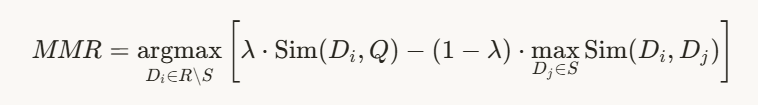

- Q = 쿼리 벡터
- R = fetch_k개의 후보 문서 풀
- S = 이미 선택된 문서 집합
- λ = lambda_mult

#### 반복 선택 과정
- fetch_k인 후보 pool에서 아래 과정을 반복하며,
- 처음 쿼리와 유사도는 높으면서 이미 뽑은 후보군과는 유사도가 낮은 것을 k개만큼 뽑는 로직

```
[후보 풀 R: fetch_k=20개]

Round 1: S={}
  → 패널티 없음 → 쿼리와 가장 유사한 문서 선택
  → S = {국내주식A}

Round 2: S={국내주식A}
  → 국내주식B: 쿼리 유사도 0.9  BUT  S와 유사도 0.95 → Score 낮음
  → 해외주식C: 쿼리 유사도 0.7  BUT  S와 유사도 0.1  → Score 높음
  → 해외주식C 선택
  → S = {국내주식A, 해외주식C}

Round 3: S에 두 문서 존재
  → 모든 후보가 S의 두 문서 모두와 비교하여 패널티 계산
  → 가장 "새로운" 카테고리 문서 선택
  ...
```

#### λ 값에 따른 동작

| lambda_mult | 수식 해석             | 결과                    |
| ----------- | ----------------- | --------------------- |
| 1.0         | 다양성 항 완전 제거       | similarity_search와 동일 |
| 0.5         | 관련성 50% + 다양성 50% | 균형 (LangChain 기본값)    |
| 0.0         | 관련성 항 완전 제거       | 쿼리 무관, 최대 다양성만        |

### 1. 벡터스토어 생성

In [12]:
# 문제 4: MMR 검색 구현
# 벡터 스토어를 먼저 구축해놔야함
  # 벡터스토어 구축방법 FAISS vectorstore..
    # Document 객체로 넣어야 하고,
      # page_content, metadata, id의 세가지 속성을 가짐

# SAMPLE_ETF_DATA = [
#     {"ticker": "KODEX200", "name": "KODEX 200", "category": "국내주식",
#      "description": "KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심으로 구성되어 있으며, 국내 주식시장 전체의 흐름을 반영합니다.",
#      "expense_ratio": 0.15, "aum_billion": 58000, "risk_level": "중간",
#      "returns": {"1m": 2.1, "3m": 5.4, "1y": 12.3, "3y": 28.5},...


from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# SAMPLE_ETF_DATA를 Document 객체로 변환
etf_docs = [
    Document(
        id=etf["ticker"],
        page_content=(
            f"{etf['name']} ({etf['ticker']})은 {etf['category']} 카테고리 ETF입니다. "
            f"위험등급 {etf['risk_level']}, 총보수 {etf['expense_ratio']}%, "
            f"1년 수익률 {etf['returns']['1y']}%. "
            f"{etf['description']}"
        ),
        metadata={
            "ticker":        etf["ticker"],
            "name":          etf["name"],
            "category":      etf["category"],
            "expense_ratio": etf["expense_ratio"],
            "aum_billion":   etf["aum_billion"],
            "risk_level":    etf["risk_level"],
            "return_1m":     etf["returns"]["1m"],
            "return_3m":     etf["returns"]["3m"],
            "return_1y":     etf["returns"]["1y"],
            "return_3y":     etf["returns"]["3y"],
        }
    )
    for etf in SAMPLE_ETF_DATA
]

vector_store_SAMPLE_ETF_DATA = FAISS.from_documents(
    documents=etf_docs,
    embedding=OpenAIEmbeddings()
)


### 2. MMR 검색 구현

In [13]:
# 벡터 스토어에서 MMR(Maximal Marginal Relevance) 검색을 구현하고 유사도 검색과 비교하세요.
  # format_results(results, method_name) 함수: 검색 결과를 포맷팅하여 출력
  # Similarity Search와 MMR Search 각각 실행 후 시간 측정
  # k값(3, 5, 10)별 카테고리 다양성 비교

import time
def format_results(results, method_name: str = "similarity"):
    label = "MMR 검색" if method_name == "mmr" else "유사도 검색"
    print(f"\n{'='*60}")
    print(f"[{label}] 결과 {len(results)}건")
    print(f"{'='*60}")

    for i, item in enumerate(results, 1):
        # similarity_search_with_score → (Document, score) 튜플
        # max_marginal_relevance_search → Document 단독
        if isinstance(item, tuple):
            doc, score = item
        else:
            doc, score = item, None

        m = doc.metadata
        print(f"\n{i}. {m['name']} ({m['ticker']})")
        print(f"   카테고리  : {m['category']} | 위험등급: {m['risk_level']}")
        print(f"   총보수    : {m['expense_ratio']}% | AUM: {m['aum_billion']:,}억원")
        print(f"   수익률    : 1M {m['return_1m']:+.1f}%  3M {m['return_3m']:+.1f}%  "
              f"1Y {m['return_1y']:+.1f}%  3Y {m['return_3y']:+.1f}%")

        if score is not None:
            print(f"   유사도    : {score:.4f}")  # FAISS는 L2거리 (낮을수록 유사)
        else:
            pass

        print(f"   {'-'*54}")
        print(f"   {doc.page_content}")

    print(f"\n{'='*60}\n")

query = "분산 투자에 적합한 ETF"

vectorstore = vector_store_SAMPLE_ETF_DATA

# Similarity Search
start = time.time()
sim_results = vectorstore.similarity_search_with_score(query, k=5)
format_results(sim_results)

# MMR Search
start = time.time()
mmr_results = vectorstore.max_marginal_relevance_search(query, k=5, fetch_k=10)
# ---- 결과 출력 + k값별 카테고리 비교 ----
format_results(mmr_results, 'mmr')


[유사도 검색] 결과 5건

1. TIGER 미국배당다우존스 (TIGERBBD)
   카테고리  : 배당 | 위험등급: 낮음
   총보수    : 0.01% | AUM: 52,000억원
   수익률    : 1M +1.8%  3M +4.2%  1Y +10.5%  3Y +32.1%
   유사도    : 0.2928
   ------------------------------------------------------
   TIGER 미국배당다우존스 (TIGERBBD)은 배당 카테고리 ETF입니다. 위험등급 낮음, 총보수 0.01%, 1년 수익률 10.5%. 미국 고배당 우량주에 투자하는 ETF. 안정적인 배당 수익과 자본 이득을 동시에 추구합니다. 월배당 지급으로 현금흐름 관리에 유리합니다.

2. TIGER 금은혼합 (TIGER금은혼합)
   카테고리  : 원자재 | 위험등급: 중간
   총보수    : 0.39% | AUM: 3,500억원
   수익률    : 1M +1.2%  3M +3.8%  1Y +15.6%  3Y +35.2%
   유사도    : 0.2946
   ------------------------------------------------------
   TIGER 금은혼합 (TIGER금은혼합)은 원자재 카테고리 ETF입니다. 위험등급 중간, 총보수 0.39%, 1년 수익률 15.6%. 금과 은에 분산 투자하는 원자재 ETF. 인플레이션 헤지 수단으로 활용되며, 지정학적 리스크 시 안전자산으로 수요 증가합니다.

3. TIGER 미국 S&P500 (TIGER미국S&P500)
   카테고리  : 해외주식 | 위험등급: 중간
   총보수    : 0.07% | AUM: 42,000억원
   수익률    : 1M +3.2%  3M +8.1%  1Y +18.7%  3Y +45.2%
   유사도    : 0.3131
   ------------------------------------------------------
   TIGER 미국 S&P5

In [14]:
# k값별 MMR 카테고리 다양성 비교
for k in [2, 4, 6, 8]:
    results = vectorstore.max_marginal_relevance_search(
        query, k=k, fetch_k=20, lambda_mult=0.5
    )
    categories = set(doc.metadata["category"] for doc in results)
    print(f"k={k} → {len(categories)}개 카테고리: {categories}")

# MMR은 k가 커질수록 카테고리가 점점 분산됨

k=2 → 2개 카테고리: {'국내주식', '배당'}
k=4 → 4개 카테고리: {'국내주식', '해외주식', '머니마켓', '배당'}
k=6 → 6개 카테고리: {'국내주식', '해외주식', '원자재', '배당', '테마', '머니마켓'}
k=8 → 8개 카테고리: {'국내주식', '해외주식', '원자재', '배당', '부동산', '테마', '채권', '머니마켓'}


---
## 문제 5: Precision@K와 Recall@K 구현

Precision@K와 Recall@K 평가 지표를 구현하세요.

**요구사항:**
- `precision_at_k(vectorstore, eval_data, k=5)` 함수 구현
- `recall_at_k(vectorstore, eval_data, k=5)` 함수 구현
- k=1~10에서 Hit Rate, MRR, Precision, Recall 4개 지표를 그래프로 비교

#### 참고 (FN 코드)
```Python
# 정답셋 전체
relevant_set = set(item["relevant_doc_ids"])   # {0, 1, 2}

# 검색된 것
retrieved_set = set(retrieved_ids)             # {0, 3, 4, 5, 6}

# TP: 검색됨 & 정답셋에 있음
tp = relevant_set & retrieved_set              # {0}

# FN: 검색 안됨 & 정답셋에 있음  ← "미검색인데 정답"
fn = relevant_set - retrieved_set              # {1, 2}

# R = TP + FN = 전체 정답 수
r  = len(relevant_set)                         # 3

```

In [15]:
# 문제 5: Precision@K, Recall@K 구현

# Precision은 TP / (TP + FP), **검색된 것(positive)** 중에서 진짜 **관련있는 것**의 비율
  # Precision@K = (상위 K개 중 관련 문서 수) / K  --- 보여준 것 중 맞은 비율
  # K가 커질수록 관련 없는 문서가 섞여 들어와 Precision은 하락
  # Precision이 낮으면 노이즈(쓸모없는문서), 환각 유발
# Recall은 TP / (TP + FN), **관련 있는 것**들 중에, **검색한 비율**
  # Recall@K = (상위 K개 중 관련 문서 수) / 전체 관련 문서 수(R)  --- 전체 관련 문서 중 찾아낸 비율
  # K가 커질 수록 관련 문서를 더 많이 포함, Recall은 상승
  # Recall이 낮으면 핵심 정보가 누락된것

# 그럼 검색된것과 관련있는건 뭘 해야하지?
# similarity_with_search로 가져오고
# 아까 만든 eval_dataset으로 테스트

  # [{'query': 'TIGER ESG리더스 ETF의 투자 대상은 어떤 기업인가요?',
  # 'relevant_doc_ids': [0],
  # 'relevant_doc_names': ['TIGER ESG리더스'],
  # 'category': 'ESG'},
  # {'query': 'ESG 관련 ETF 중에서 TIGER ESG리더스의 특징은 무엇인가요?',
  # 'relevant_doc_ids': [0],
  # 'relevant_doc_names': ['TIGER ESG리더스'],
  # 'category': 'ESG'},

def precision_at_k(vectorstore, eval_data, k=5):
    # ---- 여기에 코드 작성 ----
    # retrieved & relevant / k
    # 검색결과 K개
      # retrieved(검색됨) & relevant(정답셋에 있음)  →  TP
      # etrieved(검색됨) & irrelevant(정답셋에 없음) →  FP

    precisions = []
    for item in eval_data:
      results = vectorstore.similarity_search(item["query"], k=k)
      retrieved_ids = [r.metadata["doc_id"] for r in results]

      tp = sum(1 for rid in retrieved_ids if rid in item["relevant_doc_ids"])
      fp = k - tp
      precisions.append(tp / k)

    return np.mean(precisions)

def recall_at_k(vectorstore, eval_data, k=5):
    # retrieved & relevant / len(relevant)
    # 검색결과 K개
      # retrieved(검색됨) & relevant(정답셋에 있음)  →  TP
      # not retrieved(미검색) & relevant(정답셋에 있음) →  FN
      # R = len(relevant_doc_ids) = TP + FN (전체 정답 문서 수)
      # Recall@K = TP / (TP + FN) = TP / R

    recalls = []
    for item in eval_data:
        results = vectorstore.similarity_search(item["query"], k=k)
        retrieved_ids = [r.metadata["doc_id"] for r in results]

        tp = sum(1 for rid in retrieved_ids if rid in item["relevant_doc_ids"])
        fn = len(item["relevant_doc_ids"]) - tp  # 정답인데 못 찾은 것
        recalls.append(tp / len(item["relevant_doc_ids"]))

    return np.mean(recalls)

# k=1~10 그래프
ks = range(1, 11)
# ---- Hit Rate, MRR, Precision, Recall 4개 지표 비교 차트 ----

In [16]:
def hit_rate_at_k(vectorstore, eval_data, k=5):
    # 상위 K개 안에 정답이 1개라도 있으면 1, 없으면 0
    hits = []
    for item in eval_data:
        results = vectorstore.similarity_search(item["query"], k=k)
        retrieved_ids = [r.metadata["doc_id"] for r in results]
        hit = 1 if any(rid in item["relevant_doc_ids"] for rid in retrieved_ids) else 0
        hits.append(hit)
    return np.mean(hits)


def mrr_at_k(vectorstore, eval_data, k=5):
    # MRR = 첫 번째 정답 문서의 순위의 역수 평균
    # 1위에서 정답 → 1/1, 2위에서 정답 → 1/2, K안에 없으면 → 0
    rr_list = []
    for item in eval_data:
        results = vectorstore.similarity_search(item["query"], k=k)
        retrieved_ids = [r.metadata["doc_id"] for r in results]
        rr = 0
        for rank, rid in enumerate(retrieved_ids, 1):  # rank: 1부터 시작
            if rid in item["relevant_doc_ids"]:
                rr = 1 / rank  # 첫 번째 정답 순위의 역수
                break
        rr_list.append(rr)
    return np.mean(rr_list)


In [17]:
docs_eval = [
    Document(
        id=str(item["doc_id"]),
        page_content=item["description"],
        metadata={
            "doc_id":   item["doc_id"],
            "name":     item["name"],
            "category": item["category"],
            "market":   item["market"],
            "risk":     item["risk"],
        }
    )
    for item in etf_documents
]

vectorstore_eval = FAISS.from_documents(
    documents=docs_eval,
    embedding=OpenAIEmbeddings()
)

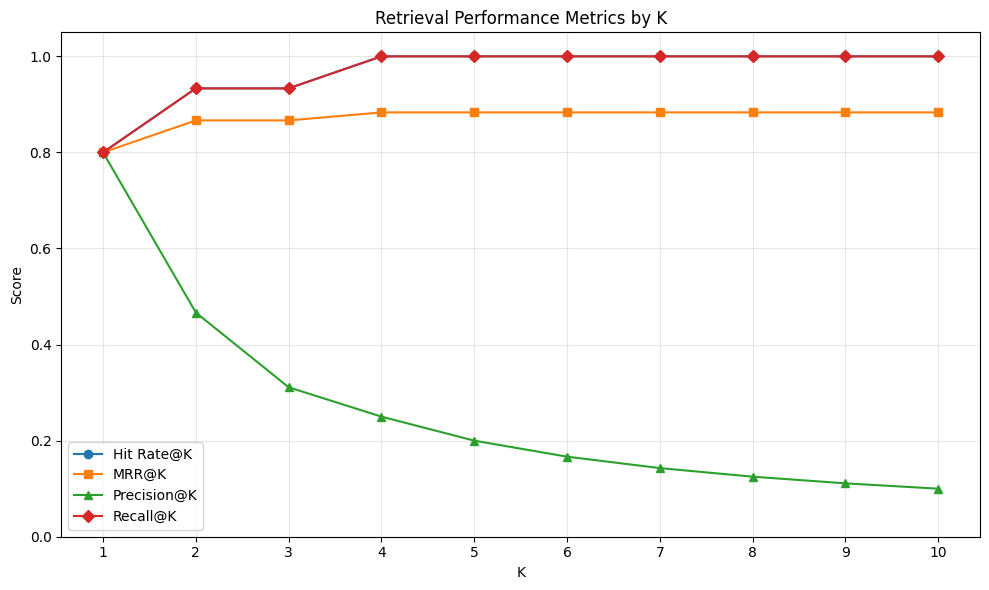

In [18]:
# k=1~10 지표 계산
ks = range(1, 11)
hit_rates  = [hit_rate_at_k(vectorstore_eval, eval_dataset, k) for k in ks]
mrrs       = [mrr_at_k(vectorstore_eval, eval_dataset, k)      for k in ks]
precisions = [precision_at_k(vectorstore_eval, eval_dataset, k) for k in ks]
recalls    = [recall_at_k(vectorstore_eval, eval_dataset, k)    for k in ks]

# 비교 차트
import matplotlib.pyplot as plt
import matplotlib

plt.figure(figsize=(10, 6))
plt.plot(ks, hit_rates,  marker="o", label="Hit Rate@K")
plt.plot(ks, mrrs,       marker="s", label="MRR@K")
plt.plot(ks, precisions, marker="^", label="Precision@K")
plt.plot(ks, recalls,    marker="D", label="Recall@K")

plt.xlabel("K")
plt.ylabel("Score")
plt.title("Retrieval Performance Metrics by K")
plt.xticks(ks)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 문제 6: NDCG 평가 리포트

Graded relevance(0, 1, 2, 3)를 사용한 NDCG 평가 리포트를 작성하세요.

**요구사항:**
- `report` 딕셔너리에 k=1,3,5,10별 Hit Rate, MRR, NDCG 저장
- JSON 파일로 저장 (`baseline_report.json`)
- 결과를 표 형태로 출력

### 📖 내용정리
#### DCG (Discounted Cumulative Gain)
- 단순히 "정답/오답" 등 이진 평가가 아니라, 순위와 관련도 점수를 함께 반영

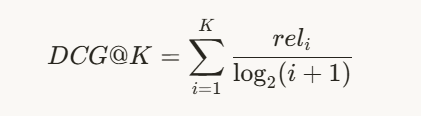

- rel_i =  i번째 문서의 관련도 점수 (0, 1, 2, 3)
- log_2(i+1) = 순위가 낮을수록 패널티(관련 문서가 뒤쪽에 나올수록 가치가 감소)
  ```
  순위 1위에 rel=3 → 3 / log2(2) = 3.0   ← 가장 가치 높음
  순위 2위에 rel=2 → 2 / log2(3) = 1.26
  순위 3위에 rel=0 → 0 / log2(4) = 0.0
  DCG@3 = 3.0 + 1.26 + 0.0 = 4.26
  ```

#### NDCG (Normalized DCG)
- DCG를 이상적 DCG(IDCG)로 나눠 0~1로 정규화
- IDCG는 관련도 높은 문서부터 정렬했을 때의 최대 DCG
  ```
  실제 검색 결과: [rel=2, rel=0, rel=3] → DCG  = 2.0 + 0 + 1.5 = 3.5
  이상적인 정렬:  [rel=3, rel=2, rel=0] → IDCG = 3.0 + 1.26 + 0 = 4.26

  NDCG@3 = 3.5 / 4.26 = 0.82

  ```

#### 동작방식

```
쿼리: "반도체 ETF 추천해줘"

similarity_search(k=3) 결과 (순서 유지):
  results[0] → doc_id=1  (VanEck Semiconductor)   ← 1위
  results[1] → doc_id=3  (iShares Aerospace)       ← 2위
  results[2] → doc_id=0  (TIGER ESG)               ← 3위

eval_dataset 정답:
  relevant_doc_ids = [1]  (VanEck Semiconductor만 정답)
```

```
DCG는 sum_1_to_k ( 2^(rel_i) - 1 / (log_2(i + 1))
- 이때 i는 문서가 뽑힌 순위

i=1 (1위 문서): rel=1 → (2^1 - 1) / log2(2) = 1 / 1.0  = 1.000
i=2 (2위 문서): rel=0 → (2^0 - 1) / log2(3) = 0 / 1.58 = 0.000
i=3 (3위 문서): rel=1 → (2^1 - 1) / log2(4) = 1 / 2.0  = 0.500
i=4 (4위 문서): rel=0 → (2^0 - 1) / log2(5) = 0 / 2.32 = 0.000
i=5 (5위 문서): rel=0 → (2^0 - 1) / log2(6) = 0 / 2.58 = 0.000

DCG = 1.000 + 0 + 0.500 + 0 + 0 = 1.500
```

In [19]:
# 문제 6: NDCG 평가 리포트

# Graded relevance(0, 1, 2, 3)를 사용한 NDCG 평가 리포트를 작성하세요.
# report 딕셔너리에 k=1,3,5,10별 Hit Rate, MRR, NDCG 저장
# JSON 파일로 저장 (baseline_report.json)
# 결과를 표 형태로 출력

def dcg_at_k(rels: list, k: int) -> float:
    """실제 순서의 DCG"""
    rels = np.array(rels[:k], dtype=float)
    if len(rels) == 0:
        return 0.0
    # (2^rel - 1) / log2(i+1)
    gains = (2 ** rels - 1) / np.log2(np.arange(2, len(rels) + 2))
    return float(np.sum(gains))

def idcg_at_k(rels: list, k: int) -> float:
    """이상적인 순서(내림차순 정렬)의 DCG"""
    ideal_rels = sorted(rels, reverse=True)  # 정답을 앞에 몰아넣어 정렬한 것
    return dcg_at_k(ideal_rels, k)

def ndcg_at_k(rels: list, k: int) -> float:
    """NDCG = DCG / IDCG"""
    idcg = idcg_at_k(rels, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(rels, k) / idcg


report = {'baseline': {}}

for k in [1, 3, 5, 10]:
    # ---- 여기에 코드 작성 ----
    # hit_rate, mrr, ndcg 계산 후 report에 저장
    hit_rate = hit_rate_at_k(vectorstore_eval, eval_dataset, k)
    mrr      = mrr_at_k(vectorstore_eval, eval_dataset, k)

    ndcg_scores = []
    for item in eval_dataset:
        results = vectorstore_eval.similarity_search(item["query"], k=k)
        rels = [1 if r.metadata["doc_id"] in item["relevant_doc_ids"]
                else 0 for r in results]
        ndcg_scores.append(ndcg_at_k(rels, k))

    ndcg = float(np.mean(ndcg_scores))

    report["baseline"][f"k={k}"] = {
        "hit_rate": hit_rate,
        "mrr":      mrr,
        "ndcg":     ndcg,
    }

# JSON 저장 + 결과 출력
# JSON 저장
with open("baseline_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

# 표 형태 출력
print(f"{'k':<6} {'Hit Rate':>10} {'MRR':>10} {'NDCG':>10}")
print("-" * 38)
for k in [1, 3, 5, 10]:
    r = report["baseline"][f"k={k}"]
    print(f"{k:<6} {r['hit_rate']:>10.4f} {r['mrr']:>10.4f} {r['ndcg']:>10.4f}")

k        Hit Rate        MRR       NDCG
--------------------------------------
1          0.8000     0.8000     0.8000
3          0.9333     0.8667     0.8841
5          1.0000     0.8833     0.9128
10         1.0000     0.8833     0.9128


---
## 문제 7: BM25 vs FAISS 비교 평가

BM25 검색 결과를 FAISS 검색 결과와 비교 평가하세요.

**요구사항:**
- `bm25_hit_rate(eval_data, k=5)` 함수 구현
- `bm25_mrr(eval_data, k=5)` 함수 구현
- BM25와 FAISS의 Hit Rate, MRR 비교 테이블 출력

### 📖 내용정리
#### BM25 (Best Matching 25)
- TF-IDF의 한계를 개선한 키워드 기반 검색 알고리즘 (FAISS는 벡터 기반 검색)
  | 문제        | 해결 파라미터     | 동작                    |
  | --------- | ----------- | --------------------- |
  | TF 포화 없음  | k1 (보통 1.5) | TF가 일정 수준 이상이면 점수가 수렴 |
  | 문서 길이 미보정 | b (보통 0.75) | 문서 길이를 avgdl로 나눠 정규화  |


#### TF 및 IDF의 한계
- TF: 포화 없음 & 문서 길이 미보정
 - 단어가 5번 나오든 50번 나오든 TF는 선형으로 계속 증가
 - 실제 관련도 차이는 거의 없음
    ```
    TF-IDF: "Python" 5번  → TF = 0.05
    TF-IDF: "Python" 50번 → TF = 0.50  ← 10배지만 실제론 비슷하게 관련
    ```
    ```
    1,000단어 문서에서 "Python" 5번 → TF = 0.005 (밀도 낮음)
    100단어 문서에서  "Python" 5번 → TF = 0.050 (밀도 높음)

    → 의미가 완전히 다른데 TF는 같다고 취급함
    ```

- IDF의 역할과 한계
  - IDF는 희귀한 단어일수록 높은 점수를 줌
    ```
    IDF = log(전체 문서 수 / 해당 단어가 등장한 문서 수)

    "the"  → 모든 문서에 등장 → IDF ≈ 0  (중요도 낮음)
    "BM25" → 일부 문서에만   → IDF 높음  (중요도 높음)
    ```
- TF-IDF = TF × IDF 로 the, a, an 같은 불용어는 IDF가 0에 가까워 자동으로 걸러나 TF의 포화·길이 문제는 해결 못함.



In [20]:
# 문제 7: BM25 vs FAISS 비교

from langchain_community.retrievers import BM25Retriever
bm25_retriever = BM25Retriever.from_documents(docs_eval)


def bm25_hit_rate(eval_data, k=5):
    # ---- 여기에 코드 작성 ----
    # Hit Rate → "정답이 k개 안에 있냐 없냐" (존재 여부)
    bm25_retriever.k = k
    hits = 0
    for item in eval_data:
        results = bm25_retriever.invoke(item["query"])
        retrieved_ids = [r.metadata["doc_id"] for r in results]
        if any(rid in item["relevant_doc_ids"] for rid in retrieved_ids):
            hits += 1
    return hits / len(eval_data)

def bm25_mrr(eval_data, k=5):
    # ---- 여기에 코드 작성 ----
    # MRR → "정답이 몇 번째에 있냐" (순위 품질)
    bm25_retriever.k = k
    rr_sum = 0
    for item in eval_data:
        results = bm25_retriever.invoke(item["query"])
        retrieved_ids = [r.metadata["doc_id"] for r in results]
        for rank, rid in enumerate(retrieved_ids, 1):
            if rid in item["relevant_doc_ids"]:
                rr_sum += 1.0 / rank
                break
    return rr_sum / len(eval_data)

# 비교 테이블 출력
print(f"{'방법':<12} | {'K':>3} | {'Hit Rate':>10} | {'MRR':>10}")
print("-" * 45)
for k in [1, 3, 5, 10]:
    faiss_hr  = hit_rate_at_k(vectorstore_eval, eval_dataset, k)
    faiss_mrr = mrr_at_k(vectorstore_eval, eval_dataset, k)
    bm25_hr   = bm25_hit_rate(eval_dataset, k)
    bm25_m    = bm25_mrr(eval_dataset, k)
    print(f"{'FAISS':<12} | {k:>3} | {faiss_hr:>10.4f} | {faiss_mrr:>10.4f}")
    print(f"{'BM25':<12} | {k:>3} | {bm25_hr:>10.4f} | {bm25_m:>10.4f}")
    print("-" * 45)

방법           |   K |   Hit Rate |        MRR
---------------------------------------------
FAISS        |   1 |     0.8000 |     0.8000
BM25         |   1 |     0.8000 |     0.8000
---------------------------------------------
FAISS        |   3 |     0.9333 |     0.8667
BM25         |   3 |     0.8667 |     0.8333
---------------------------------------------
FAISS        |   5 |     1.0000 |     0.8833
BM25         |   5 |     1.0000 |     0.8600
---------------------------------------------
FAISS        |  10 |     1.0000 |     0.8833
BM25         |  10 |     1.0000 |     0.8600
---------------------------------------------


---
## 문제 8: Alpha 최적화

Alpha 값을 0.0~1.0까지 0.1 단위로 변경하며 Hit Rate를 측정하고 최적값을 찾으세요.

**요구사항:**
- alpha를 0.0~1.0 범위에서 0.1 간격으로 탐색
- 각 alpha별 Hit Rate@5 출력
- 최적 alpha와 Hit Rate를 `checkpoint` 딕셔너리에 저장
- `project2_data/checkpoints/hybrid_config.json`으로 저장

```
alpha = 0.0  →  BM25  100%  (키워드만)
alpha = 0.5  →  BM25 50% + FAISS 50%  (혼합)
alpha = 1.0  →  FAISS 100%  (벡터만)
```

In [21]:
def hybrid_search(query, k=5, alpha=0.5):
    """
    alpha = 0.0 → BM25 100%
    alpha = 1.0 → FAISS 100%
    """
    rrf_k = 60
    rrf_scores = {}

    # FAISS
    faiss_results = vectorstore_eval.similarity_search(query, k=k*2)
    for rank, doc in enumerate(faiss_results, start=1):
        doc_id = doc.metadata["doc_id"]
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + alpha / (rrf_k + rank)

    # BM25
    bm25_retriever.k = k * 2
    bm25_results = bm25_retriever.invoke(query)
    for rank, doc in enumerate(bm25_results, start=1):
        doc_id = doc.metadata["doc_id"]
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + (1 - alpha) / (rrf_k + rank)

    ranked = sorted(rrf_scores, key=rrf_scores.get, reverse=True)
    return ranked[:k]

In [22]:
# 문제 8: Alpha 최적화
# "0~1 사이에서 어떤 비중일 때 Hit Rate가 가장 높냐"

best_alpha, best_hr = 0, 0

for a in np.arange(0, 1.1, 0.1):
    # ---- 여기에 코드 작성 ----
    # hybrid_search()로 Hit Rate 측정
    alpha = round(float(a), 1)

    hits = 0
    for item in eval_dataset:
        retrieved_ids = hybrid_search(item["query"], k=5, alpha=alpha)
        if any(rid in item["relevant_doc_ids"] for rid in retrieved_ids):
            hits += 1
    hr = hits / len(eval_dataset)

    print(f"alpha={alpha:.1f} | Hit Rate@5: {hr:.4f}")

    if hr > best_hr:
        best_hr, best_alpha = hr, alpha

print(f"\n최적 Alpha: {best_alpha}, Hit Rate@5: {best_hr:.4f}")

# 최적값 저장
checkpoint = {'best_alpha': best_alpha, 'best_hr': best_hr}
# JSON 저장
os.makedirs("project2_data/checkpoints", exist_ok=True)
with open("project2_data/checkpoints/hybrid_config.json", "w") as f:
    json.dump(checkpoint, f, indent=2)

alpha=0.0 | Hit Rate@5: 1.0000
alpha=0.1 | Hit Rate@5: 1.0000
alpha=0.2 | Hit Rate@5: 1.0000
alpha=0.3 | Hit Rate@5: 1.0000
alpha=0.4 | Hit Rate@5: 1.0000
alpha=0.5 | Hit Rate@5: 1.0000
alpha=0.6 | Hit Rate@5: 1.0000
alpha=0.7 | Hit Rate@5: 1.0000
alpha=0.8 | Hit Rate@5: 1.0000
alpha=0.9 | Hit Rate@5: 1.0000
alpha=1.0 | Hit Rate@5: 1.0000

최적 Alpha: 0.0, Hit Rate@5: 1.0000


#### MRR

In [23]:
best_alpha, best_hr = 0, 0

for a in np.arange(0, 1.1, 0.1):
    alpha = round(float(a), 1)

    mrr_scores = []
    for item in eval_dataset:
        retrieved_ids = hybrid_search(item["query"], k=5, alpha=alpha)
        rr = 0.0
        for rank, rid in enumerate(retrieved_ids, start=1):
            if rid in item["relevant_doc_ids"]:
                rr = 1.0 / rank
                break
        mrr_scores.append(rr)

    hr = float(np.mean(mrr_scores))  # MRR로 대체
    print(f"alpha={alpha:.1f} | MRR@5: {hr:.4f}")

    if hr > best_hr:
        best_hr, best_alpha = hr, alpha

print(f"\n최적 Alpha: {best_alpha}, MRR@5: {best_hr:.4f}")

alpha=0.0 | MRR@5: 0.8600
alpha=0.1 | MRR@5: 0.8600
alpha=0.2 | MRR@5: 0.8600
alpha=0.3 | MRR@5: 0.8267
alpha=0.4 | MRR@5: 0.8300
alpha=0.5 | MRR@5: 0.8333
alpha=0.6 | MRR@5: 0.9000
alpha=0.7 | MRR@5: 0.8889
alpha=0.8 | MRR@5: 0.8889
alpha=0.9 | MRR@5: 0.8833
alpha=1.0 | MRR@5: 0.8833

최적 Alpha: 0.6, MRR@5: 0.9000


---
## 문제 9: 도메인 특화 동의어 사전

도메인 특화 동의어 사전을 만들고 쿼리 확장 성능을 비교하세요.

**요구사항:**
- `finance_synonyms` 딕셔너리: ETF, 배당, 안정, 성장, 미국 등의 동의어
- `synonym_expand(query)` 함수: 동의어로 확장된 쿼리 리스트 반환
- Baseline vs Synonym 확장 Hit Rate 비교

#### 로직 확인
```
finance_synonyms = {
    "ETF":  ["상장지수펀드", "인덱스펀드", "펀드"],
    "배당":  ["분배금", "dividend"],
}

query = "ETF 배당 추천해줘"
expanded = ["ETF 배당 추천해줘"]  # 원본
```

- 1회
```
if "ETF" in "ETF 배당 추천해줘":  # True
    expanded.append("상장지수펀드 배당 추천해줘")
    expanded.append("인덱스펀드 배당 추천해줘")
    expanded.append("펀드 배당 추천해줘")

```

- 2회
```
if "배당" in "ETF 배당 추천해줘":  # True
    expanded.append("ETF 분배금 추천해줘")
    expanded.append("ETF dividend 추천해줘")

```

In [24]:
# 문제 9: 도메인 동의어 사전
finance_synonyms = {
    "ETF":  ["상장지수펀드", "인덱스펀드", "펀드"],
    "배당":  ["분배금", "dividend", "배당금"],
    "안정":  ["안전", "저위험", "채권"],
    "성장":  ["growth", "기술주", "고수익"],
    "미국":  ["S&P500", "나스닥", "US"],
}


def synonym_expand(query):
    # ---- 여기에 코드 작성 ----
    # query에 포함된 키워드를 동의어로 확장
    expanded = [query] # 원본 쿼리는 항상 리스트에 포함

    for keyword, synonyms in finance_synonyms.items():
        if keyword in query:
            for syn in synonyms:
                expanded.append(query.replace(keyword, syn))
    return list(set(expanded))

# Baseline vs Synonym Hit Rate 비교
def synonym_hit_rate(eval_data, k=5):
    hits = 0
    for item in eval_data:
        queries = synonym_expand(item["query"])  # ["ETF 추천", "펀드 추천", ...]
        retrieved_ids = set()
        for q in queries:
            results = vectorstore_eval.similarity_search(q, k=k)
            for r in results:
                retrieved_ids.add(r.metadata["doc_id"])
        if any(rid in item["relevant_doc_ids"] for rid in retrieved_ids):
            hits += 1
    return hits / len(eval_data)

baseline_hr = hit_rate_at_k(vectorstore_eval, eval_dataset, k=5)
synonym_hr  = synonym_hit_rate(eval_dataset, k=5)

print(f"{'방법':<15} | {'Hit Rate@5':>10}")
print("-" * 30)
print(f"{'Baseline':<15} | {baseline_hr:>10.4f}")
print(f"{'Synonym 확장':<15} | {synonym_hr:>10.4f}")

방법              | Hit Rate@5
------------------------------
Baseline        |     1.0000
Synonym 확장      |     1.0000


---
## 문제 10: 커스텀 Multi-Query Retriever

커스텀 프롬프트로 Multi-Query Retriever를 설정하세요.

**요구사항:**
- `custom_prompt` PromptTemplate 정의 (ETF 검색 전문가 역할)
- `retriever_custom` = MultiQueryRetriever 생성
- `retriever_custom.invoke()`로 검색 실행 후 결과 출력

#### 동의어 사전 대신 LLM이 자동으로 쿼리를 여러 개 생성

In [39]:
import langchain
print("LangChain 버전:", langchain.__version__)

LangChain 버전: 1.2.15


In [40]:
# LangChain 0.2.x 이상
from langchain.retrievers.multi_query import MultiQueryRetriever

# LangChain 1.0 이상 (최신)
from langchain_community.retrievers import MultiQueryRetriever

TypeError: Cannot create a consistent method resolution
order (MRO) for bases ABC, Generic

In [43]:
!pip install -qU langchain langchain-community langchain-core

In [46]:
# 문제 10: 커스텀 Multi-Query Retriever
#from langchain.prompts import PromptTemplate
#from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_core.prompts import PromptTemplate

# 1. 커스텀 프롬프트 정의 (ETF 검색 전문가 역할)
custom_prompt = PromptTemplate(
    input_variables=["question"],
    template="""
            당신은 ETF 및 금융 상품 검색 전문가입니다.
            아래 질문에 대해 벡터 데이터베이스 검색을 위한 3가지 다른 버전의 질문을 생성하세요.
            각 질문은 서로 다른 관점(투자 목적, 상품 유형, 운용 전략 등)을 반영해야 합니다.
            줄바꿈으로 구분하여 질문만 반환하세요.

            원본 질문: {question}
            """
    )
# ---- 여기에 코드 작성 ----
# retriever_custom = MultiQueryRetriever.from_llm(...)

# 2. MultiQueryRetriever 생성
def multi_query_retrieve(query, k=3):
    # LLM으로 쿼리 3개 생성
    chain = custom_prompt | llm
    response = chain.invoke({"question": query})
    queries = [q.strip() for q in response.content.strip().split("\n") if q.strip()]
    queries = [query] + queries  # 원본 포함

    # 각 쿼리로 검색 후 결과 합치기
    retrieved = {}
    for q in queries:
        results = vectorstore_eval.similarity_search(q, k=k)
        for doc in results:
            doc_id = doc.metadata["doc_id"]
            if doc_id not in retrieved:
                retrieved[doc_id] = doc
    return list(retrieved.values())


# results_custom = retriever_custom.invoke(...)

# 3. 검색 실행
query = "안정적인 ETF 추천해줘"
#results = retriever_custom.invoke(query)
results = multi_query_retrieve("안정적인 ETF 추천해줘")

print(f"검색된 문서 수: {len(results)}")
for doc in results:
    print(f"- doc_id: {doc.metadata['doc_id']} | {doc.page_content[:50]}")

검색된 문서 수: 3
- doc_id: 3 | iShares U.S. Aerospace & Defense ETF는 미국의 우주항공 및 방
- doc_id: 0 | 'TIGER ESG리더스'는 국내 ESG 투자에 초점을 둔 ETF로, 환경, 사회, 지배구
- doc_id: 1 | VanEck Semiconductor ETF는 미국 시장의 반도체 산업에 투자하는 ETF로


---
## 문제 11: 검색 비교 대시보드

모든 검색 방법의 결과를 나란히 비교하는 Gradio UI를 만드세요.

**요구사항:**
- `full_comparison(query, top_k)` 함수: FAISS/BM25/Hybrid 결과 비교
- `show_history()` 함수: 최근 검색 이력 표시
- `gr.Blocks`로 탭 UI 구성 (검색 탭 + 이력 탭)

In [47]:
# 문제 11: 검색 비교 대시보드
import gradio as gr

search_history = []

def full_comparison(query, top_k):
    top_k = int(top_k)

    # FAISS 검색
    faiss_results = vectorstore_eval.similarity_search(query, k=top_k)
    faiss_text = "\n".join([
        f"{i+1}. [doc_id={r.metadata['doc_id']}] {r.page_content[:80]}"
        for i, r in enumerate(faiss_results)
    ])

    # BM25 검색
    bm25_retriever.k = top_k
    bm25_results = bm25_retriever.invoke(query)
    bm25_text = "\n".join([
        f"{i+1}. [doc_id={r.metadata['doc_id']}] {r.page_content[:80]}"
        for i, r in enumerate(bm25_results)
    ])

    # Hybrid 검색
    hybrid_ids = hybrid_search(query, k=top_k, alpha=best_alpha)
    hybrid_text = "\n".join([
        f"{i+1}. [doc_id={doc_id}]"
        for i, doc_id in enumerate(hybrid_ids)
    ])

    # 이력 저장
    search_history.append({
        "query": query,
        "top_k": top_k,
    })

    return faiss_text, bm25_text, hybrid_text


def show_history():
    if not search_history:
        return "검색 이력이 없습니다."
    return "\n".join([
        f"{i+1}. [{h['top_k']}개] {h['query']}"
        for i, h in enumerate(search_history)
    ])


# gr.Blocks 탭 UI
with gr.Blocks(title="검색 비교 대시보드") as demo:
    gr.Markdown("# 🔍 검색 방법 비교 대시보드")

    with gr.Tabs():
        # 탭 1: 검색 비교
        with gr.Tab("검색 비교"):
            with gr.Row():
                query_input = gr.Textbox(label="검색 쿼리", placeholder="ETF 추천해줘")
                topk_input  = gr.Slider(minimum=1, maximum=10, value=5, step=1, label="Top K")
            search_btn = gr.Button("검색 실행", variant="primary")

            with gr.Row():
                faiss_out  = gr.Textbox(label="FAISS (벡터 검색)", lines=10)
                bm25_out   = gr.Textbox(label="BM25 (키워드 검색)", lines=10)
                hybrid_out = gr.Textbox(label="Hybrid (혼합 검색)", lines=10)

            search_btn.click(
                fn=full_comparison,
                inputs=[query_input, topk_input],
                outputs=[faiss_out, bm25_out, hybrid_out]
            )

        # 탭 2: 검색 이력
        with gr.Tab("검색 이력"):
            history_btn = gr.Button("이력 불러오기")
            history_out = gr.Textbox(label="최근 검색 이력", lines=10)
            history_btn.click(fn=show_history, inputs=[], outputs=history_out)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://86446bd6e1292232d1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Weekend 1 요약

### 달성한 것들
1. **ETF 데이터셋 구축**: 15개 ETF 문서 생성 및 벡터화
2. **평가 프레임워크**: Hit Rate, MRR, NDCG 구현
3. **BM25 검색**: 키워드 기반 검색 구축
4. **하이브리드 검색**: 벡터+BM25 앙상블
5. **고급 기법**: Query Expansion, Multi-Query
6. **Gradio 대시보드**: 인터랙티브 검색 UI

### Weekend 2 예고
- 리랭킹과 답변 품질 평가
- BLEU, ROUGE, BERTScore, LLM-as-Judge 평가
- 종합 평가 파이프라인과 품질 대시보드